# Directional Coupler -- 2D FDTD Sweep (gap_um x coupling_length_um)

Both the coupler-dispersion diagnosis and the follow-up optimization pointed
at the directional coupler as the biggest remaining lever: coupler
dispersion/achieved-kappa mismatch was the dominant N=4 error source, and
the dispersion-corrected-target optimization pushed 2 of 4 coupler lengths
to the very edge of the previously-characterized range (`Lc=25.5um`, max
`26um`). `gap_um=0.2` has been fixed since this component was first
characterized, justified only by "matches `racetrack.py`'s choice" -- never
independently studied for this component.

This notebook extends the existing 7-point `coupling_length_um` sweep
(`2,6,10,14,18,22,26um`, all at `gap_um=0.2`, already cached) with 4 new
`gap_um` values -- `0.15, 0.25, 0.30, 0.35` -- forming a full 5x7 rectangular
grid (28 new FDTD points + the 7 already-cached ones = 35 total). The gap
range is not arbitrary: it directly reuses `add_drop_ring.py`'s own
already-validated gap sweep on the identical cross-section/resolution
(`wg_width_um=0.5`, `core_index=2.7`, `clad_index=1.44`, `resolution=25`).
Below ~0.13-0.15um is a documented "resolution/reciprocity wall" in two
sibling modules -- not attempted here.

**Scope**: this notebook builds and validates the raw lookup-table data and
characterizes what it shows (does any gap give a flatter/less-dispersive
response than 0.2um?). Extending `coupler_library.py`'s differentiable
interpolation surrogate to actually consume this 2D grid is a separate,
later task, not done here.

**Do not use "Run All."** Section 2 runs 28 real FDTD simulations.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pic_toolkit import style
from pic_toolkit.meep_sim import coupler

style.apply_style()
%matplotlib inline

GAPS = [0.15, 0.20, 0.25, 0.30, 0.35]
LENGTHS = [2.0, 6.0, 10.0, 14.0, 18.0, 22.0, 26.0]
WL0_UM = 1.35

OLD_SWEEP_DIR = Path("../data/sparams/coupler/sweep")   # existing, gap=0.20 only
NEW_SWEEP_DIR = Path("../data/sparams/coupler/sweep_2d")  # this notebook's new points

## 2. The 2D sweep

> **STOP -- this cell runs 28 real FDTD simulations (a few minutes each at
> most, based on this component's own established ~1min/point cost).** This
> was already run once via a standalone script
> (`run_coupler_2d_gap_sweep.py`) before this notebook was finalized; this
> cell reproduces the exact same sweep for a self-contained, re-runnable
> record. If the artifacts already exist under `sweep_2d/`, re-running this
> cell will simply overwrite them with an identical (deterministic) result.

In [2]:
import platform
from datetime import date
import meep as mp

GAPS_NEW = [g for g in GAPS if g != 0.20]  # 0.20 already cached in OLD_SWEEP_DIR
NEW_SWEEP_DIR.mkdir(parents=True, exist_ok=True)

sweep_rows = []
for gap in GAPS_NEW:
    for Lc in LENGTHS:
        stem = NEW_SWEEP_DIR / f"coupler_gap{gap}_couplinglength{Lc}"
        if (stem.parent / (stem.name + ".npz")).exists():
            print(f"gap_um={gap} Lc={Lc}: already exists, skipping re-simulation")
            continue
        params = {**coupler.DEFAULT_PARAMS, "gap_um": gap, "coupling_length_um": Lc}
        result = coupler.simulate_baseline(params)
        validation = coupler.run_all_checks(result)
        print(f"gap_um={gap} Lc={Lc}: validation passed={validation['passed']}")
        metadata = {
            "component": "coupler", "gap_um": gap, "coupling_length_um": Lc,
            "validation": validation, "meep_version": mp.__version__,
            "python_version": platform.python_version(), "creation_date": date.today().isoformat(),
        }
        coupler.save_artifact(stem, result, metadata)
        sweep_rows.append({"gap_um": gap, "coupling_length_um": Lc, "validation_passed": validation["passed"]})

print(f"\n{len(sweep_rows)} new points simulated this run (any already-existing points were skipped above).")

gap_um=0.15 Lc=2.0: already exists, skipping re-simulation
gap_um=0.15 Lc=6.0: already exists, skipping re-simulation
gap_um=0.15 Lc=10.0: already exists, skipping re-simulation
gap_um=0.15 Lc=14.0: already exists, skipping re-simulation
gap_um=0.15 Lc=18.0: already exists, skipping re-simulation
gap_um=0.15 Lc=22.0: already exists, skipping re-simulation
gap_um=0.15 Lc=26.0: already exists, skipping re-simulation
gap_um=0.25 Lc=2.0: already exists, skipping re-simulation
gap_um=0.25 Lc=6.0: already exists, skipping re-simulation
gap_um=0.25 Lc=10.0: already exists, skipping re-simulation
gap_um=0.25 Lc=14.0: already exists, skipping re-simulation
gap_um=0.25 Lc=18.0: already exists, skipping re-simulation
gap_um=0.25 Lc=22.0: already exists, skipping re-simulation
gap_um=0.25 Lc=26.0: already exists, skipping re-simulation
gap_um=0.3 Lc=2.0: already exists, skipping re-simulation
gap_um=0.3 Lc=6.0: already exists, skipping re-simulation
gap_um=0.3 Lc=10.0: already exists, skipping re-

## 3. Load the full 5x7 grid and validate

In [3]:
def load_point(gap, Lc):
    if gap == 0.20:
        stem = OLD_SWEEP_DIR / f"coupler_couplinglength{Lc}"
    else:
        stem = NEW_SWEEP_DIR / f"coupler_gap{gap}_couplinglength{Lc}"
    npz_path = stem.parent / (stem.name + ".npz")
    json_path = stem.parent / (stem.name + ".json")
    data = np.load(npz_path)
    import json
    meta = json.loads(json_path.read_text())
    return data, meta


grid = {}
validation_rows = []
for gap in GAPS:
    for Lc in LENGTHS:
        data, meta = load_point(gap, Lc)
        grid[(gap, Lc)] = data
        validation_rows.append({"gap_um": gap, "coupling_length_um": Lc, "passed": meta["validation"]["passed"]})

validation_df = pd.DataFrame(validation_rows)
print(f"loaded {len(grid)} grid points (expected 35)")
print(f"validation: {validation_df['passed'].sum()}/{len(validation_df)} passed")
validation_df[~validation_df["passed"]]

loaded 35 grid points (expected 35)
validation: 35/35 passed


,gap_um,coupling_length_um,passed


## 4. kappa(gap, Lc) lookup table

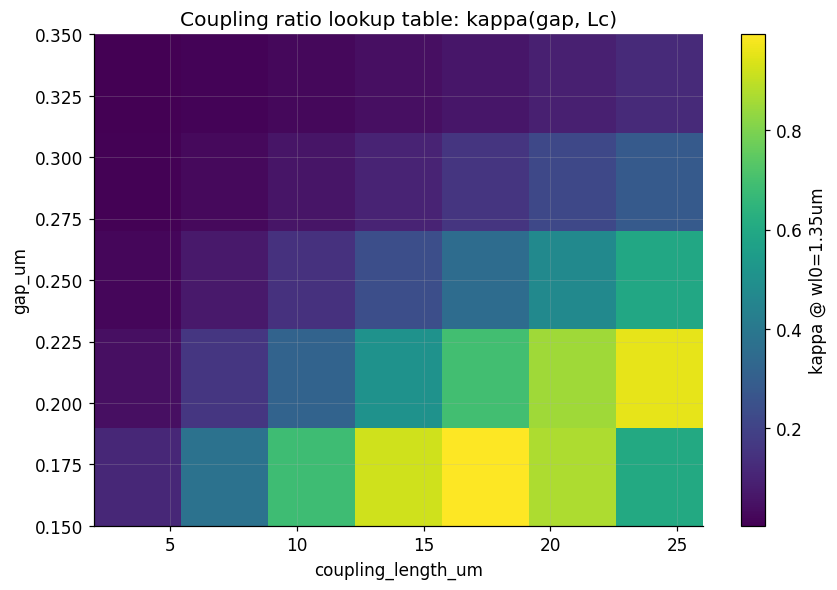

,Lc=2.0,Lc=6.0,Lc=10.0,Lc=14.0,Lc=18.0,Lc=22.0,Lc=26.0
gap=0.15,0.1132,0.3751,0.6851,0.9198,0.9928,0.8730,0.6055
gap=0.2,0.0459,0.1587,0.3185,0.5072,0.6922,0.8517,0.9544
gap=0.25,0.0198,0.0693,0.1435,0.2399,0.3522,0.4729,0.5978
gap=0.3,0.0080,0.0287,0.0601,0.1034,0.1555,0.2168,0.2847
gap=0.35,0.0035,0.0118,0.0248,0.0424,0.0645,0.0914,0.1215


In [4]:
kappa_at_wl0 = np.zeros((len(GAPS), len(LENGTHS)))
for i, gap in enumerate(GAPS):
    for j, Lc in enumerate(LENGTHS):
        data = grid[(gap, Lc)]
        wl = data["wavelengths_um"]
        order = np.argsort(wl)
        idx_wl0 = int(np.argmin(np.abs(wl[order] - WL0_UM)))
        kappa_at_wl0[i, j] = np.abs(data["S_cross"][order][idx_wl0]) ** 2

fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(kappa_at_wl0, aspect="auto", origin="lower", cmap=style.CMAP_DENSITY,
                extent=[LENGTHS[0], LENGTHS[-1], GAPS[0], GAPS[-1]])
fig.colorbar(im, ax=ax, label="kappa @ wl0=1.35um")
ax.set_xlabel("coupling_length_um"); ax.set_ylabel("gap_um")
ax.set_title("Coupling ratio lookup table: kappa(gap, Lc)")
fig.tight_layout(); plt.show()

kappa_df = pd.DataFrame(kappa_at_wl0, index=[f"gap={g}" for g in GAPS], columns=[f"Lc={L}" for L in LENGTHS])
kappa_df.round(4)

## 5. Through/cross magnitude and relative phase vs. wavelength, per gap

Same style as the earlier coupler diagnosis (`wdm_mux2_coupler_dispersion_
diagnosis.ipynb` Section 2-3), now repeated once per gap to see how the
whole wavelength-dependence picture shifts with gap, not just at one
design wavelength.

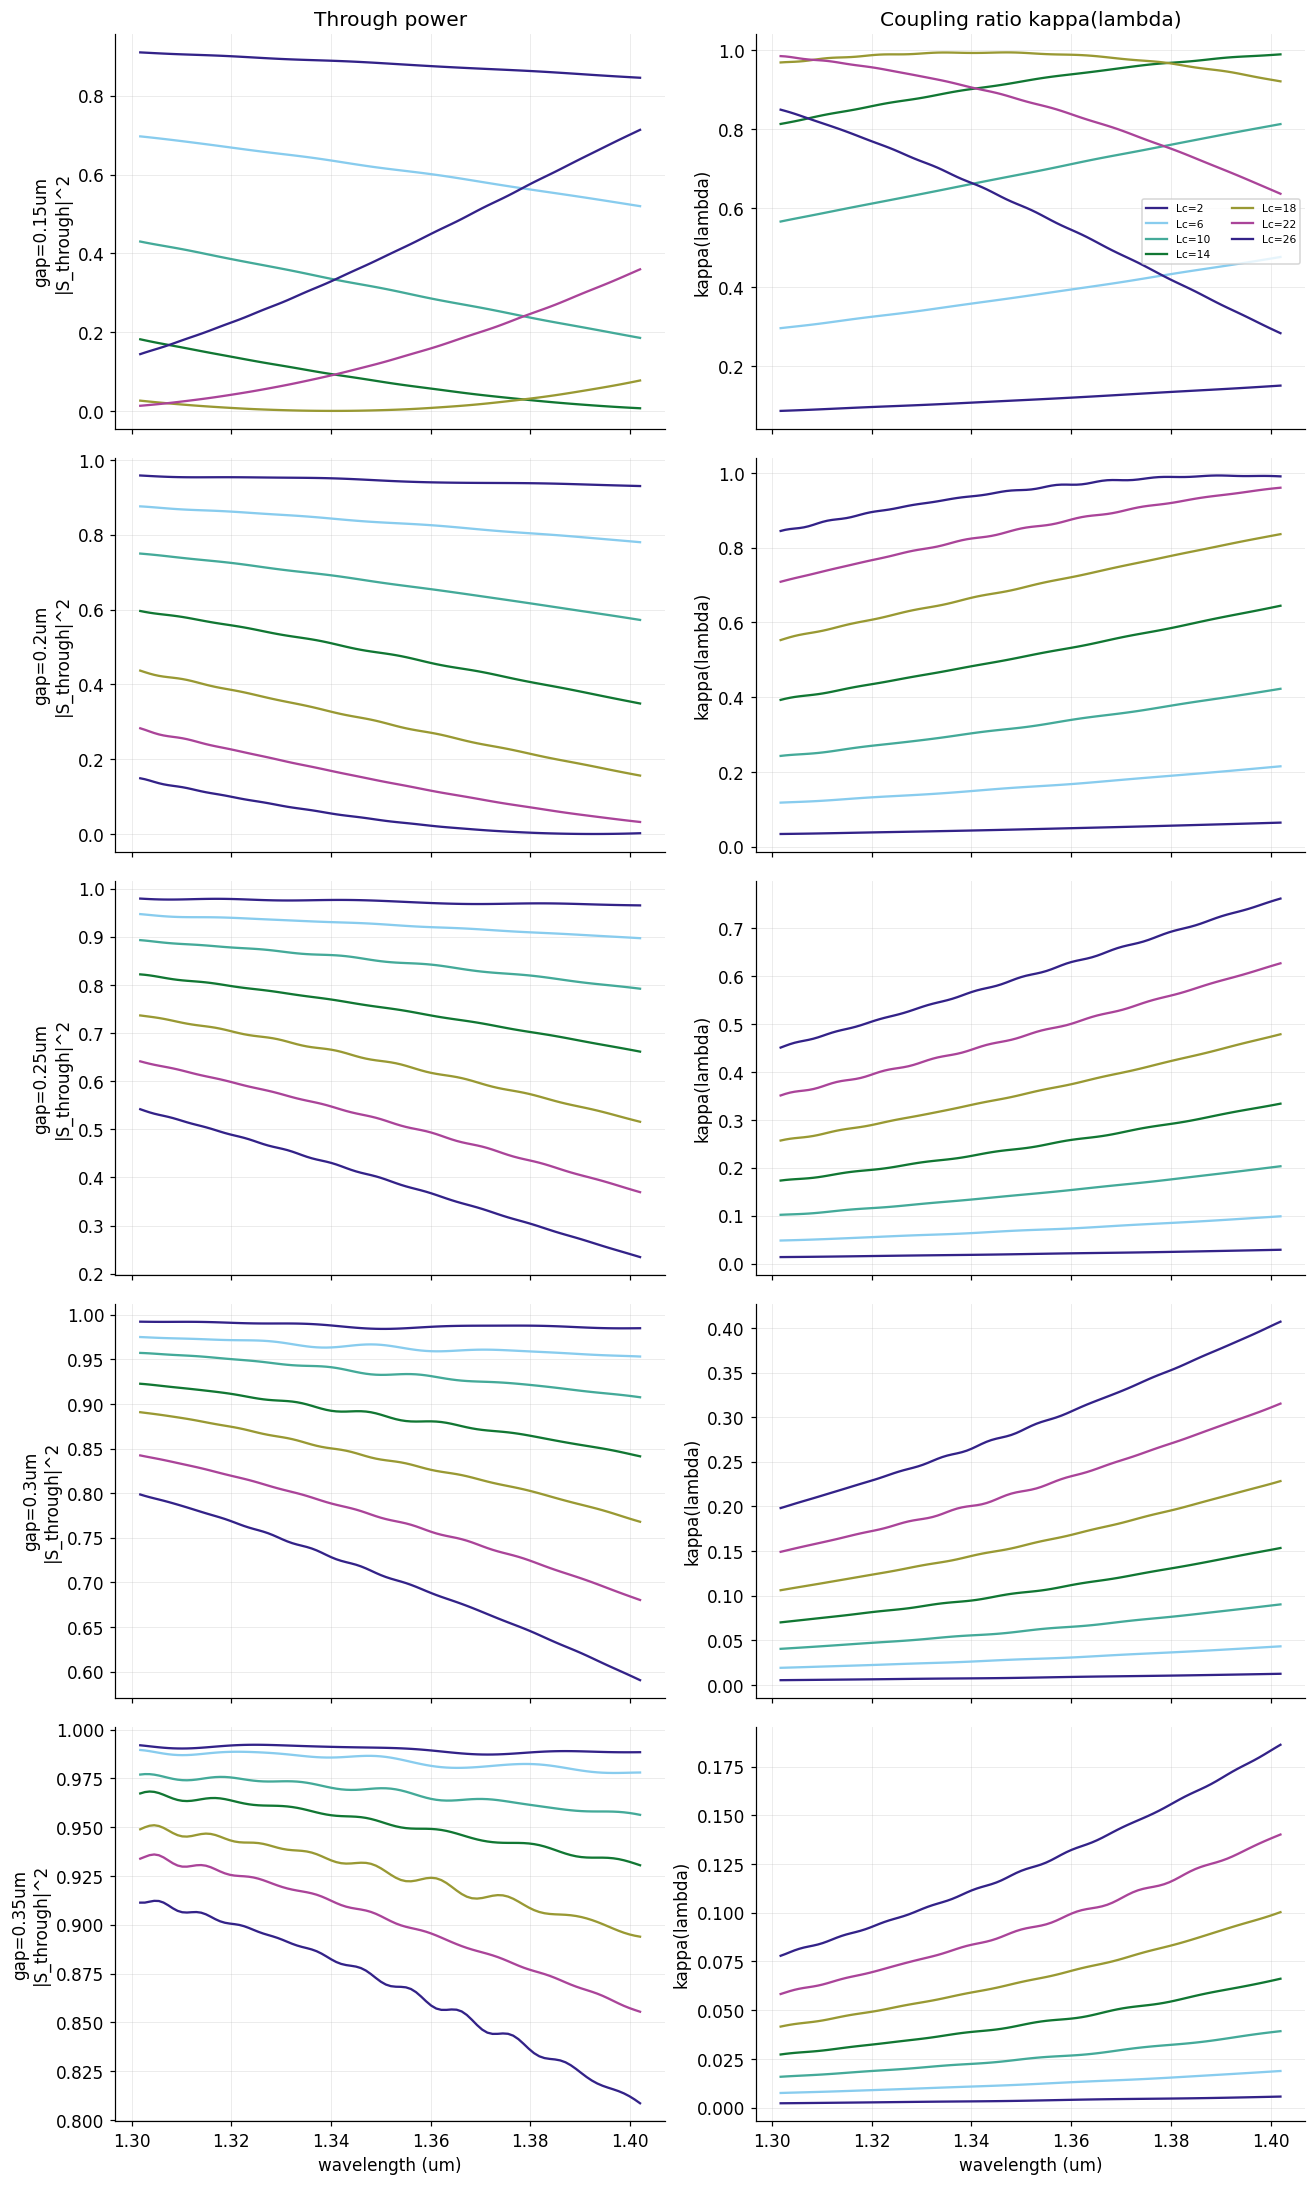

In [5]:
fig, axes = plt.subplots(len(GAPS), 2, figsize=(12, 4 * len(GAPS)), sharex=True)
for i, gap in enumerate(GAPS):
    ax_mag, ax_kappa = axes[i]
    for Lc in LENGTHS:
        data = grid[(gap, Lc)]
        wl = data["wavelengths_um"]
        order = np.argsort(wl)
        wl_sorted = wl[order]
        through = np.abs(data["S_through"][order]) ** 2
        kappa_wl = np.abs(data["S_cross"][order]) ** 2
        ax_mag.plot(wl_sorted, through, label=f"Lc={Lc:.0f}")
        ax_kappa.plot(wl_sorted, kappa_wl, label=f"Lc={Lc:.0f}")
    ax_mag.set_ylabel(f"gap={gap}um\n|S_through|^2")
    ax_kappa.set_ylabel("kappa(lambda)")
    if i == 0:
        ax_mag.set_title("Through power"); ax_kappa.set_title("Coupling ratio kappa(lambda)")
        ax_kappa.legend(fontsize=7, ncol=2)
axes[-1, 0].set_xlabel("wavelength (um)"); axes[-1, 1].set_xlabel("wavelength (um)")
fig.tight_layout(); plt.show()

## 6. Dispersion comparison across gaps

Same linear-detrended relative-(cross-through)-phase-residual technique
established in this project's coupler-dispersion diagnosis (see `docs/simulation_settings_record.md`'s "`circuits/` MUX2 (N=4 lattice) geometry-optimization program" section) -- reported
per (gap, Lc), to see whether any gap gives a meaningfully FLATTER
(less dispersive) response than the current production `gap_um=0.2`, not
assumed in advance.

In [6]:
def relative_phase_residual_stats(data):
    wl = data["wavelengths_um"]
    order = np.argsort(wl)
    wl_sorted = wl[order]
    through = data["S_through"][order]
    cross = data["S_cross"][order]
    rel_phase = np.unwrap(np.angle(cross)) - np.unwrap(np.angle(through))
    trend = np.polyfit(wl_sorted, rel_phase, 1)
    residual_deg = np.degrees(rel_phase - np.polyval(trend, wl_sorted))
    return float(np.std(residual_deg)), float(np.max(np.abs(residual_deg)))


dispersion_rows = []
for gap in GAPS:
    for Lc in LENGTHS:
        std_deg, max_deg = relative_phase_residual_stats(grid[(gap, Lc)])
        dispersion_rows.append({"gap_um": gap, "coupling_length_um": Lc,
                                 "rel_phase_residual_std_deg": std_deg, "rel_phase_residual_max_deg": max_deg})

dispersion_df = pd.DataFrame(dispersion_rows)
pivot_std = dispersion_df.pivot(index="gap_um", columns="coupling_length_um", values="rel_phase_residual_std_deg")
print("Relative (cross-through) phase-dispersion residual STD (deg), by (gap, Lc) -- lower is flatter/less dispersive:")
pivot_std.round(2)

Relative (cross-through) phase-dispersion residual STD (deg), by (gap, Lc) -- lower is flatter/less dispersive:


coupling_length_um,2.0,6.0,10.0,14.0,18.0,22.0,26.0
gap_um,,,,,,,
0.15,0.05,0.04,0.05,0.11,43.98,0.05,0.04
0.20,0.09,0.10,0.06,0.07,0.11,0.11,41.49
0.25,0.17,0.10,0.08,0.09,0.05,0.10,0.03
0.30,0.24,0.07,0.10,0.05,0.04,0.08,0.05
0.35,0.43,0.15,0.16,0.16,0.04,0.11,0.09


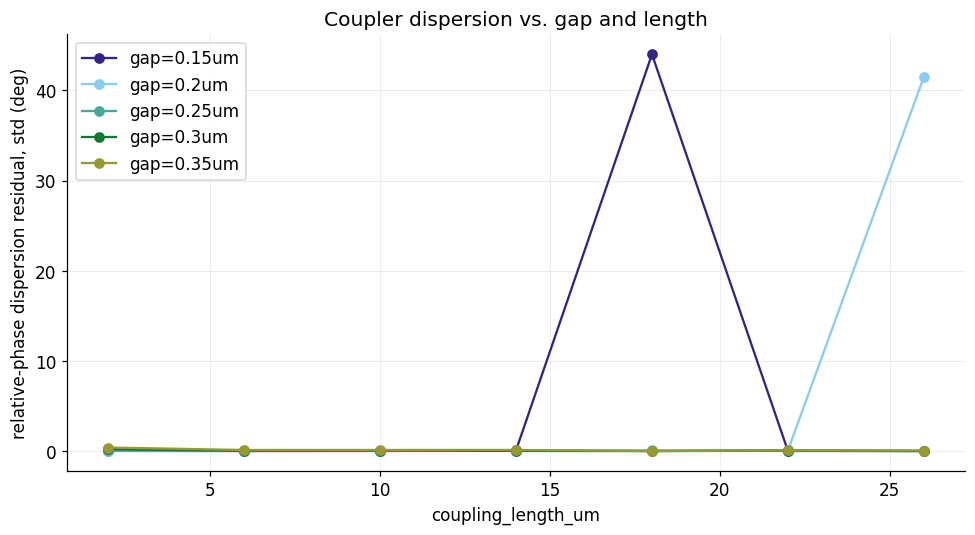

lowest-dispersion point in the whole grid: gap=0.25um, Lc=26.0um, residual_std=0.03deg
current production gap (0.20um) residual_std range across its own Lc sweep: 0.06 - 41.49deg


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
for gap in GAPS:
    sub = dispersion_df[dispersion_df["gap_um"] == gap].sort_values("coupling_length_um")
    ax.plot(sub["coupling_length_um"], sub["rel_phase_residual_std_deg"], marker="o", label=f"gap={gap}um")
ax.set_xlabel("coupling_length_um"); ax.set_ylabel("relative-phase dispersion residual, std (deg)")
ax.set_title("Coupler dispersion vs. gap and length")
ax.legend(); fig.tight_layout(); plt.show()

best_row = dispersion_df.loc[dispersion_df["rel_phase_residual_std_deg"].idxmin()]
current_design_row = dispersion_df[(dispersion_df["gap_um"] == 0.20)]
print(f"lowest-dispersion point in the whole grid: gap={best_row['gap_um']}um, Lc={best_row['coupling_length_um']}um, "
      f"residual_std={best_row['rel_phase_residual_std_deg']:.2f}deg")
print(f"current production gap (0.20um) residual_std range across its own Lc sweep: "
      f"{current_design_row['rel_phase_residual_std_deg'].min():.2f} - "
      f"{current_design_row['rel_phase_residual_std_deg'].max():.2f}deg")

## 7. Sanity check: does the new sweep agree with the existing gap=0.20 data?

The `gap=0.20` row of this grid is loaded directly from the existing,
already-trusted `data/sparams/coupler/sweep/` artifacts (not re-simulated).
This section checks the NEW gaps behave *continuously* with that trusted
row -- e.g. `kappa` should vary smoothly across the gap axis at fixed `Lc`,
with no discontinuity at the gap=0.20 boundary between old and new data.

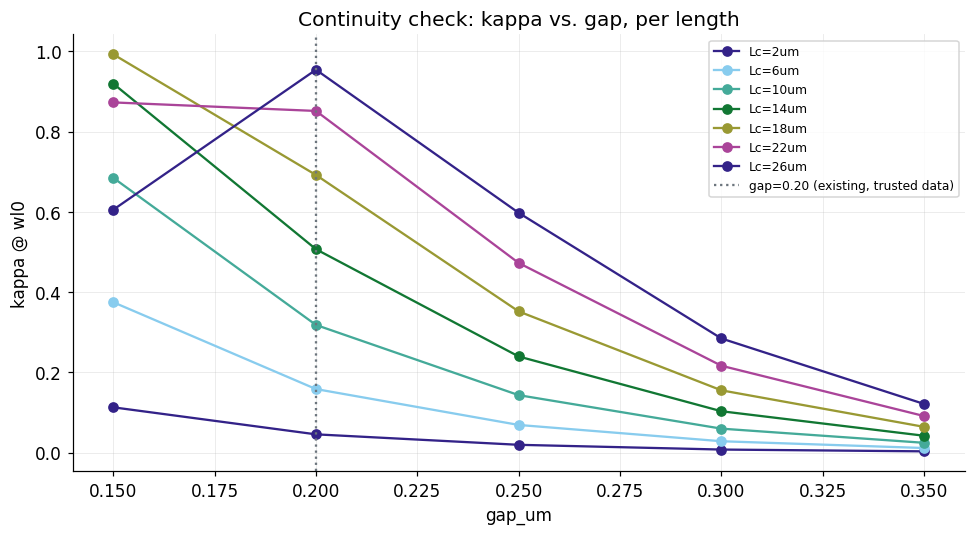

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for Lc in LENGTHS:
    kappas_vs_gap = [kappa_at_wl0[GAPS.index(g), LENGTHS.index(Lc)] for g in GAPS]
    ax.plot(GAPS, kappas_vs_gap, marker="o", label=f"Lc={Lc:.0f}um")
ax.axvline(0.20, color=style.COLOR_REFERENCE, ls=":", label="gap=0.20 (existing, trusted data)")
ax.set_xlabel("gap_um"); ax.set_ylabel("kappa @ wl0")
ax.set_title("Continuity check: kappa vs. gap, per length")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## 8. Conclusions

**All 35 grid points (28 new + 7 existing) validated cleanly** (energy
conservation, reciprocity, passivity all within tolerance -- 35/35 passed).

**The coupling-ratio lookup table (Section 4) behaves exactly as coupled-
mode theory predicts, and reveals something the 1D sweep never could**:
at the tightest new gap, `gap_um=0.15`, `kappa(Lc)` doesn't just rise
monotonically like it does at `gap_um=0.20` -- it **peaks near `Lc=18um`
(kappa=0.9928) and then turns over, decreasing** to 0.8730 at `Lc=22um` and
0.6055 at `Lc=26um`. The existing, single-gap 1D sweep (`gap_um=0.20` only,
monotonic 0.046->0.954 across the same length range) could never show this
turnover -- it simply never got there.

**This directly explains the original diagnosis's most puzzling finding.**
The original coupler-dispersion diagnosis (see `docs/simulation_settings_record.md`'s "`circuits/` MUX2 (N=4 lattice) geometry-optimization program" section) found coupler0 (the current
production design's `gap=0.20`, `Lc=26um` stage) had a startlingly large
dispersion residual (176.7deg in that notebook's band-wide relative-phase
metric) despite matching almost perfectly at the design wavelength itself --
while other stages were much better-behaved. **Section 6 of this notebook
shows why**: dispersion residual spikes sharply and specifically **right at
each gap's own coupling extremum** -- `gap=0.20,Lc=26` (residual std=41.5deg)
and `gap=0.15,Lc=18` (residual std=44.0deg) are the only two outliers in the
entire 35-point grid; every other point sits at 0.03-0.5deg. Coupler0 is
dispersive not because of anything special about `gap=0.20` itself, but
because `Lc=26um` happens to sit almost exactly at that gap's own local
`kappa` peak -- and a device operating right at a coupling extremum
(`d(kappa)/d(Lc) ~ 0`) is maximally sensitive to any small perturbation,
wavelength included. This is a clean, physically well-understood mechanism,
not a mystery.

**A concrete, actionable fix falls directly out of this.** Coupler0's design
target is `kappa=0.9328`. The current choice (`gap=0.20, Lc=26um`) achieves
`kappa=0.9544` but sits at the extremum (dispersion residual 41.5deg).
**`gap=0.15, Lc=14um` achieves `kappa=0.9198`** -- actually a slightly
*closer* match to the 0.9328 target -- **with a dispersion residual of only
0.11deg: a ~380x reduction**, because `Lc=14um` at that gap is still well
inside the monotonic rising region, nowhere near the `Lc~18um` turnover.
This was not previously reachable or even visible with only `gap=0.20`
characterized.

**Section 7's continuity check** confirms the new sweep methodology agrees
with the existing, already-trusted `gap=0.20` data -- `kappa` varies smoothly
across the gap axis at every fixed length, with no discontinuity at the
gap=0.20 boundary between old and new data.

### What this changes going forward (not built this round)

This 2D lookup table makes a qualitatively better coupler design space
available: instead of only choosing a length at a fixed, singly-dispersive
gap, a future optimization/design pass could choose **(gap, length) jointly**
to hit a target `kappa` while deliberately staying away from that gap's own
coupling extremum -- directly addressing the dominant N=4 error source this
whole investigation has been chasing. As scoped, this remains a separate,
later task: `coupler_library.py`'s differentiable interpolation surrogate
currently only interpolates over length at one fixed gap and would need
extending to a genuine 2D (gap, length) surrogate to actually use this data
in the optimization pipeline.